Mounting the drive to load the data sets.

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [3]:
train_df = pd.read_csv('/content/drive/MyDrive/NLP_Assignment/data/processed/train.csv')
validate_df = pd.read_csv('/content/drive/MyDrive/NLP_Assignment/data/processed/validate.csv')
test_df = pd.read_csv('/content/drive/MyDrive/NLP_Assignment/data/processed/test.csv')

Check text length to pick max_len

In [4]:
word_counts = train_df['content'].apply(lambda x: len(x.split()))
print(word_counts.describe())

p95_word_count = word_counts.quantile(0.95)
print("95th percentile:", p95_word_count)

count    31059.000000
mean       234.497827
std        178.540806
min          4.000000
25%        128.000000
50%        212.000000
75%        293.500000
max       4788.000000
Name: content, dtype: float64
95th percentile: 519.0


Fit tokenizer on train dataset

In [5]:
vocab_size = 10000  # cap vocabulary to most frequent words

tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['content'])

print("Vocabulary size found:", len(tokenizer.word_index))

Vocabulary size found: 80410


Convert text to sequences

In [6]:
train_sequences = tokenizer.texts_to_sequences(train_df['content'])
validate_sequences = tokenizer.texts_to_sequences(validate_df['content'])
test_sequences = tokenizer.texts_to_sequences(test_df['content'])

Pad to fixed length using the max_len

In [7]:
max_len = int(p95_word_count)

train_padded = pad_sequences(train_sequences,
                            maxlen=max_len,
                            padding='post',
                            truncating='post')

validate_padded = pad_sequences(validate_sequences,
                                maxlen=max_len,
                                padding='post',
                                truncating='post')

test_padded = pad_sequences(test_sequences,
                            maxlen=max_len,
                            padding='post',
                            truncating='post')

print("Train padded shape:", train_padded.shape)

Train padded shape: (31059, 519)


In [8]:
y_train = train_df['label'].values
y_validate = validate_df['label'].values
y_test = test_df['label'].values

Building the model

In [9]:
embedding_dim = 128

model = Sequential()
model.add(Input(shape=(max_len,)))
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim))
model.add(Conv1D(filters=128, kernel_size=5, activation='relu'))
model.add(GlobalMaxPooling1D())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 519, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 515, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,370,369 (5.23 MB)

 Trainable params: 1,370,369 (5.23 MB)

 Non-trainable params: 0 (0.00 B)

Compile

In [10]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Training the model

In [11]:
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(
    train_padded, y_train,
    validation_data=(validate_padded, y_validate),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
971/971 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.9492 - loss: 0.1185 - val_accuracy: 0.9910 - val_loss: 0.0238
Epoch 2/10
971/971 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.9959 - loss: 0.0152 - val_accuracy: 0.9933 - val_loss: 0.0199
Epoch 3/10
971/971 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9992 - loss: 0.0035 - val_accuracy: 0.9920 - val_loss: 0.0207
Epoch 4/10
971/971 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9995 - loss: 0.0017 - val_accuracy: 0.9858 - val_loss: 0.0527


Evaluating the model

122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Validation Accuracy: 0.9933024214322514

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1790
           1       1.00      0.99      0.99      2092

    accuracy                           0.99      3882
   macro avg       0.99      0.99      0.99      3882
weighted avg       0.99      0.99      0.99      3882


Confusion Matrix:



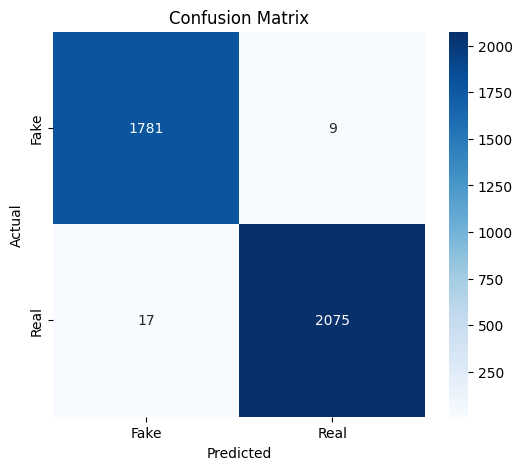

In [12]:
val_probs = model.predict(validate_padded)
val_preds = (val_probs > 0.5).astype(int)

print("Validation Accuracy:", accuracy_score(y_validate, val_preds))
print("\nClassification Report:\n", classification_report(y_validate, val_preds))
print("\nConfusion Matrix:\n")

# plot confusion matrix
cm = confusion_matrix(y_validate, val_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Saving the model and tokenizer

In [13]:
save_dir = '/content/drive/MyDrive/NLP_Assignment/models/CNN'
os.makedirs(save_dir, exist_ok=True)

model.save(os.path.join(save_dir, 'cnn_model.keras'))

with open(os.path.join(save_dir, 'cnn_tokenizer.pkl'), 'wb') as f:
    pickle.dump(tokenizer, f)

print("Model and tokenizer saved to:", save_dir)

Model and tokenizer saved to: /content/drive/MyDrive/NLP_Assignment/models/CNN
